In [1]:
import ast
import re
import numpy as np
import pandas as pd
from flatbuffers.packer import int32
from rdkit import Chem
import tensorflow as tf
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

2025-03-19 17:38:09.705319: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
%run ../PyFiles/matrix_to_mol.py

In [3]:
#use in get_data.py
def normalize_graph_features(x):
    x = re.sub(r'(?<=[0-9])\s+(?=[0-9])', ',', x)
    x = re.sub(r'\]\s+\[', '],[', x)
    return x

In [4]:
%run ../PyFiles/preprocess.py

In [5]:
qm9 = pd.read_csv("../Data/qm9.csv")
qm9.tail()

,mol_id,smiles,A,B,C,mu,alpha,homo,lumo,gap,...,g298,cv,u0_atom,u298_atom,h298_atom,g298_atom,Morgan_fingerprint,adj_matrix,node_features,node_count
133880,gdb_133881,C1C2C3C4C5OC14C5N23,3.59483,2.19899,1.90423,1.6637,69.37,-0.2254,0.0588,0.2842,...,-400.663098,23.658,-1603.983913,-1614.898804,-1623.788097,-1492.819438,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 0 1]\n [...,"[[6], [6], [6], [6], [6], [8], [6], [6], [7]]",9
133881,gdb_133882,C1N2C3C2C2C4OC12C34,3.65648,2.14237,1.90439,1.2976,69.52,-0.2393,0.0608,0.3002,...,-400.658942,23.697,-1601.376613,-1612.291504,-1621.181424,-1490.211511,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 0 1 0]\n [1 0 1 1 0 0 0 0 0]\n [...,"[[6], [7], [6], [6], [6], [6], [8], [6], [6]]",9
133882,gdb_133883,C1N2C3C4C5C2C13CN45,3.67118,2.14314,1.89501,1.2480,73.60,-0.2233,0.0720,0.2953,...,-380.783148,23.972,-1667.045429,-1678.830048,-1688.312964,-1549.143391,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 1 0 0 0]\n [...,"[[6], [7], [6], [6], [6], [6], [6], [6], [7]]",9
133883,gdb_133884,C1N2C3C4C5CC13C2C45,3.52845,2.15131,1.86582,1.9576,77.40,-0.2122,0.0881,0.3003,...,-364.749650,24.796,-1794.600439,-1807.210860,-1817.286772,-1670.349892,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 1 0]\n [...,"[[6], [7], [6], [6], [6], [6], [6], [6], [6]]",9
133884,gdb_133885,C1N2C3C4C5OC13C2C45,3.64015,2.21764,1.93793,0.8626,69.48,-0.2316,0.0742,0.3058,...,-400.662186,23.434,-1603.471865,-1614.455155,-1623.345075,-1492.247150,[0 0 0 ... 0 0 0],[[0 1 0 0 0 0 1 0 0]\n [1 0 1 0 0 0 0 1 0]\n [...,"[[6], [7], [6], [6], [6], [8], [6], [6], [6]]",9


In [6]:
#use in get_data.py
qm9['adj_matrix'] = qm9["adj_matrix"].apply(normalize_graph_features)
qm9['node_features'] = qm9["node_features"].apply(normalize_graph_features)

In [7]:
#use in get_data.py
qm9['adj_matrix'] = qm9['adj_matrix'].apply(lambda x: np.array(ast.literal_eval(x)))
qm9['node_features'] = qm9['node_features'].apply(lambda x: ast.literal_eval(x))

In [8]:
valid_atom_types = [1, 6, 7, 8, 9]
num_features = len(valid_atom_types)

max_size = max(matrix.shape[0] for matrix in qm9['adj_matrix'])

one_hot_node_features = [
    preprocess_node_features(nf, valid_atom_types, num_nodes)
    for nf, num_nodes in zip(qm9['node_features'], qm9['node_count'])
]
one_hot_node_features = [
    pad_one_hot_features(features, max_size, num_features)
    for features in one_hot_node_features
]

In [9]:
node_features = tf.argmax(one_hot_node_features, axis = -1)
node_features = np.array(node_features)
node_counts = qm9['node_count']
adj_matrices_train = qm9['adj_matrix'][:1000]
sliced_features = []
train_smiles = []

for node_feature, node_count in zip(node_features, node_counts):
  sliced_features.append(node_feature[:node_count])

feature_map = {
    0 : valid_atom_types[0],
    1 : valid_atom_types[1],
    2 : valid_atom_types[2],
    3 : valid_atom_types[3],
    4 : valid_atom_types[4]
}
mapped_features = [0] * len(sliced_features)

for i in range(len(sliced_features)):
    mapped_features[i] = [feature_map[value] for value in sliced_features[i]]

node_features_small = mapped_features[:1000]
train_structs = [[0] * 2 for _ in range(1000)]

for i in range(len(adj_matrices_train)):
    for j in range(0, 2):
        if j == 0:
            train_structs[i][j] = adj_matrices_train[i]
        else:
            train_structs[i][j] = node_features_small[i]

for struct in train_structs:
    train_smiles.append(Chem.MolToSmiles(adjacency_matrix_to_mol(struct)))

In [10]:
qm9['adj_matrix'] = qm9['adj_matrix'].apply(lambda x: pad_adj_matrix(x, max_size))

In [11]:
adj_matrices = np.stack(qm9['adj_matrix'].values)
one_hot_node_features = np.stack(one_hot_node_features)

In [12]:
adj_matrices_small = adj_matrices[:1000]
one_hot_node_features_small = one_hot_node_features[:1000]
dataset_small = create_dataset(adj_matrices_small, one_hot_node_features_small, batch_size=32)

In [13]:
dataset = create_dataset(adj_matrices, one_hot_node_features, batch_size=32)

In [14]:
%run ../PyFiles/rewards.py
%run ../PyFiles/graph_generator_capstone.py
%run ../PyFiles/original_discriminator.py
%run ../PyFiles/HierarchicalDiscriminator.py

In [15]:
generator = GraphGenerator(num_nodes=max_size, node_features=num_features, latent_dim=128)
discriminator = HierarchicalDiscriminator(num_nodes=max_size, node_features=num_features)

d_loss, g_loss, r_loss, scl_loss = generator.fit(dataset_small, discriminator, train_smiles, epochs=10)

[17:39:47] WARNING: not removing hydrogen atom without neighbors
[17:39:47] WARNING: not removing hydrogen atom without neighbors


Epoch 1/10 D Loss: 1.5979 G Loss: 0.5079 R Loss: 14.3523 Scaled Loss: 868807.1943


[17:39:47] WARNING: not removing hydrogen atom without neighbors
[17:39:47] WARNING: not removing hydrogen atom without neighbors


Epoch 1/10 D Loss: 1.5380 G Loss: 0.5577 R Loss: 14.3523 Scaled Loss: 953980.9756


[17:39:47] WARNING: not removing hydrogen atom without neighbors
[17:39:47] WARNING: not removing hydrogen atom without neighbors


...

[17:39:58] WARNING: not removing hydrogen atom without neighbors
[17:39:58] WARNING: not removing hydrogen atom without neighbors


Epoch 1/10 D Loss: 0.8363 G Loss: 1.6260 R Loss: 14.3523 Scaled Loss: 2781358.0659


[17:39:58] WARNING: not removing hydrogen atom without neighbors
[17:39:58] WARNING: not removing hydrogen atom without neighbors
2025-03-19 17:39:58.711639: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Epoch 1/10 D Loss: 0.8345 G Loss: 1.6505 R Loss: 14.3523 Scaled Loss: 2823329.6407


[17:39:58] WARNING: not removing hydrogen atom without neighbors
[17:39:58] WARNING: not removing hydrogen atom without neighbors
[17:39:59] WARNING: not removing hydrogen atom without neighbors
[17:39:59] WARNING: not removing hydrogen atom without neighbors
[17:39:59] WARNING: not removing hydrogen atom without neighbors
[17:39:59] WARNING: not removing hydrogen atom without neighbors
[17:40:00] WARNING: not removing hydrogen atom without neighbors
[17:40:00] WARNING: not removing hydrogen atom without neighbors
[17:40:00] WARNING: not removing hydrogen atom without neighbors
[17:40:00] WARNING: not removing hydrogen atom without neighbors
[17:40:00] WARNING: not removing hydrogen atom without neighbors
[17:40:00] WARNING: not removing hydrogen atom without neighbors
[17:40:01] WARNING: not removing hydrogen atom without neighbors
[17:40:01] WARNING: not removing hydrogen atom without neighbors
[17:40:01] WARNING: not removing hydrogen atom without neighbors
[17:40:01] WARNING: not r

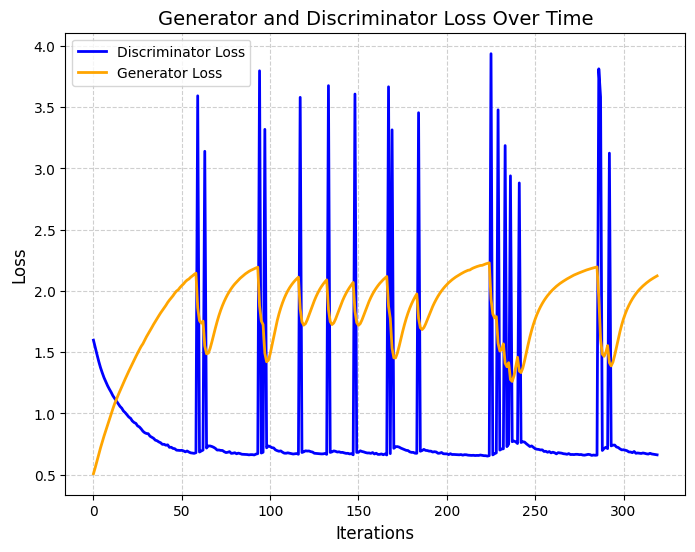

In [16]:
plt.figure(figsize=(8, 6)) 
plt.plot(d_loss, label="Discriminator Loss", color="blue", linewidth=2)  
plt.plot(g_loss, label="Generator Loss", color="orange", linewidth=2)  

plt.xlabel("Iterations", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.title("Generator and Discriminator Loss Over Time", fontsize=14)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6) 

plt.show()

### Notes
    smoothing reduced the high generator loss and made the discriminator loss not go as low

    random flipping of the labels cuased the spikes in loss for the discriminator and made the generator stagnat and not go as high